# Make Transit Skims

Create skims between 2020 Census tracts within Chicago.  Start from GTFS files for April 2025, corresponding to survey data. 

Computes transit travel times between every pair of in-scope tracts, for five weekday time
periods, using [r5py](https://r5py.readthedocs.io/) over the CTA, Pace and Metra GTFS feeds.

**Prerequisites**
- The `rh_pricing` conda environment (see `README.md`) — r5py needs Java 21.
- `data/cook_county.osm.pbf` — run `Download OSM.ipynb` first to create it.
- The three GTFS feeds and `tract_2020_district.csv` in `data/`.

Outputs one Parquet file per time period in `out/`, each a long table of
`from_id, to_id, travel_time_min`.

In [1]:
import os, datetime
import geopandas as gpd
import pandas as pd
from r5py import TransportNetwork, TravelTimeMatrix, TransportMode

DATA_DIR = "data"
OUT_DIR  = "out"

OSM_PBF    = f"{DATA_DIR}/cook_county.osm.pbf"
GTFS_FILES = [
    f"{DATA_DIR}/gtfs-cta-202504170110.zip",
    f"{DATA_DIR}/gtfs-metra-202510301823.zip",
    f"{DATA_DIR}/gtfs-pace-202502270021.zip",
]
TRACTS_CSV = f"{DATA_DIR}/tract_2020_district.csv"

# Service date: a representative weekday. April 16, 2025 is a Wednesday, and all three
# feeds have regular weekday service in effect on that date.
SERVICE_DATE = datetime.date(2025, 4, 16)

# Five time periods as (name, start time, duration). r5py samples departures across the
# whole window and reports the median travel time, so each skim reflects average service
# over that period. 'night' spans 10pm-6am and crosses midnight into the next (still
# weekday) morning.
TIME_PERIODS = [
    ("night",   datetime.time(22, 0), datetime.timedelta(hours=8)),
    ("am_peak", datetime.time( 6, 0), datetime.timedelta(hours=3)),
    ("midday",  datetime.time( 9, 0), datetime.timedelta(hours=7)),
    ("pm_peak", datetime.time(16, 0), datetime.timedelta(hours=3)),
    ("evening", datetime.time(19, 0), datetime.timedelta(hours=3)),
]

# Trips longer than this are reported as unreachable (NaN).
MAX_TIME = datetime.timedelta(hours=3)

# For a quick test run, set to an int (e.g. 25) to limit the number of origins. None = all.
MAX_ORIGINS = None

os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load tract centroids (origins & destinations)

Read the tract equivalency file, drop `External` tracts (outside the City of Chicago), and
build point origins/destinations from the centroid lat-lon in the CRS r5py expects (EPSG:4326).

In [2]:
tracts = pd.read_csv(TRACTS_CSV, dtype={"GEOID": str})
tracts = tracts[tracts["RH_Zone"] != "External"].copy()

tracts["lat"] = tracts["INTPTLAT"].astype(float)
tracts["lon"] = tracts["INTPTLON"].astype(float)

points = gpd.GeoDataFrame(
    {"id": tracts["GEOID"].values},
    geometry=gpd.points_from_xy(tracts["lon"], tracts["lat"]),
    crs="EPSG:4326",
)

origins = points if MAX_ORIGINS is None else points.iloc[:MAX_ORIGINS].copy()
print(f"{len(points)} in-scope Chicago tracts; using {len(origins)} origins x {len(points)} destinations")
origins.head()

792 in-scope Chicago tracts; using 792 origins x 792 destinations


,id,geometry
0,17031510300,POINT (-87.57498 41.71574)
1,17031520100,POINT (-87.52943 41.72112)
2,17031590700,POINT (-87.66279 41.82605)
3,17031600400,POINT (-87.64393 41.84172)
4,17031830600,POINT (-87.67357 42.0017)


## 2. Build the multimodal transport network

This loads the OSM street network and all three GTFS feeds into a single routable network.
The first build is the slow step (a few minutes) and is memory-hungry; r5py/R5 claims up to
80% of available RAM by default.

In [3]:
transport_network = TransportNetwork(OSM_PBF, GTFS_FILES)

## 3. Compute a travel-time skim for each time period

For each period, r5py runs RAPTOR for departures sampled across the whole window and returns
the **median** travel time per OD pair (in minutes; `NaN` if unreachable within `MAX_TIME`).
Wider windows (night, midday) sample more departure minutes and take proportionally longer —
start with `MAX_ORIGINS` set to a small number to smoke-test before the full run.

In [ ]:
def compute_period(name, start_time, window):
    departure = datetime.datetime.combine(SERVICE_DATE, start_time)
    print(f"[{name}] departure {departure}, window {window} ...")

    # r5py 1.x: TravelTimeMatrix computes on construction and *is* the result
    # GeoDataFrame (the old TravelTimeMatrixComputer + .compute_travel_times() is gone).
    skim = TravelTimeMatrix(
        transport_network,
        origins=origins,
        destinations=points,
        departure=departure,
        departure_time_window=window,
        max_time=MAX_TIME,
        transport_modes=[TransportMode.TRANSIT, TransportMode.WALK],
        snap_to_network=True,
    ).rename(columns={"travel_time": "travel_time_min"})

    reachable = skim["travel_time_min"].notna().mean() * 100
    print(f"[{name}] {len(skim):,} OD pairs, {reachable:.1f}% reachable -> {out_path}")
    return skim

skims = {name: compute_period(name, start, window) for name, start, window in TIME_PERIODS}

[night] departure 2025-04-16 22:00:00, window 8:00:00 ...
[night] 627,264 OD pairs, 35.1% reachable -> out/transit_skim_night.parquet
[am_peak] departure 2025-04-16 06:00:00, window 3:00:00 ...
[am_peak] 627,264 OD pairs, 99.9% reachable -> out/transit_skim_am_peak.parquet
[midday] departure 2025-04-16 09:00:00, window 7:00:00 ...
[midday] 627,264 OD pairs, 99.9% reachable -> out/transit_skim_midday.parquet
[pm_peak] departure 2025-04-16 16:00:00, window 3:00:00 ...
[pm_peak] 627,264 OD pairs, 99.9% reachable -> out/transit_skim_pm_peak.parquet
[evening] departure 2025-04-16 19:00:00, window 3:00:00 ...
[evening] 627,264 OD pairs, 99.9% reachable -> out/transit_skim_evening.parquet


## 4. Quick look

In [5]:
am = skims["am_peak"]
print("AM peak median travel time (min):", round(am["travel_time_min"].median(), 1))
am.head()

AM peak median travel time (min): 67.0


,from_id,to_id,travel_time_min
0,17031510300,17031510300,0.0
1,17031510300,17031520100,41.0
2,17031510300,17031590700,74.0
3,17031510300,17031600400,69.0
4,17031510300,17031830600,102.0


In [8]:
skims['night'].describe()

,travel_time_min
count,220234.000000
mean,111.980398
std,43.828986
min,0.000000
25%,80.000000
50%,117.000000
75%,149.000000
max,194.000000


In [7]:
skims['am_peak'].describe()

,travel_time_min
count,626487.000000
mean,67.987937
std,23.478433
min,0.000000
25%,51.000000
50%,67.000000
75%,84.000000
max,181.000000


In [9]:
skims['midday'].describe()

,travel_time_min
count,626479.000000
mean,70.466938
std,24.065104
min,0.000000
25%,53.000000
50%,70.000000
75%,87.000000
max,181.000000


In [10]:
skims['pm_peak'].describe()

,travel_time_min
count,626491.000000
mean,70.164251
std,23.768758
min,0.000000
25%,53.000000
50%,70.000000
75%,86.000000
max,181.000000


In [11]:
skims['evening'].describe()

,travel_time_min
count,626450.000000
mean,69.711465
std,23.829254
min,0.000000
25%,52.000000
50%,69.000000
75%,86.000000
max,181.000000


Two "gotchas" to check:

1. It looks like the intrazonals have a travel time of zero.  We'll assume transit is not available, and only walk is used. 

2. 99.9% of the zone pairs are reachable during the day, but only 35.1% at night.  Check what values are used here. 

<Axes: >

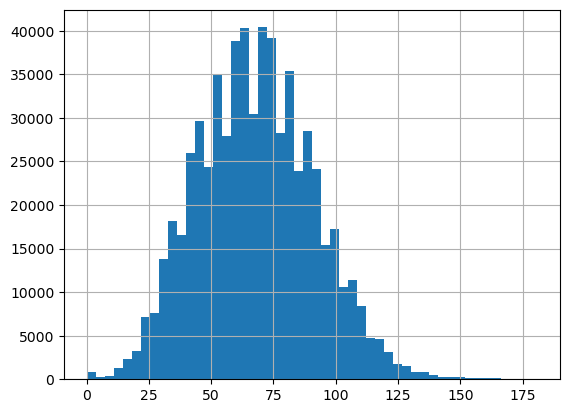

In [12]:
skims['am_peak']['travel_time_min'].hist(bins=50)

In [14]:
am[am['travel_time_min'].isna()]

,from_id,to_id,travel_time_min
2061,17031590700,17031838800,NaN
2853,17031600400,17031838800,NaN
3645,17031830600,17031838800,NaN
4437,17031830800,17031838800,NaN
5229,17031830700,17031838800,NaN
...,...,...,...
623781,17031063200,17031838800,NaN
624573,17031320600,17031838800,NaN
625365,17031030604,17031838800,NaN
626157,17031031300,17031838800,NaN


It looks like it's just one zone that is not connected during the day --> Look at the map to see which census tract this is. -->  When I look at it, it is the Census tract for Lake Calumet.  It's an industrial area with not much in it otherwise, so just leave it as missing.  What we'll do instead is replace the missing value with a transit travel time of 999 minutes.  

In [17]:
# replace missing values with 999 transit travel time.
skims['night']['travel_time_min']   = skims['night']['travel_time_min'].fillna(999)
skims['am_peak']['travel_time_min'] = skims['am_peak']['travel_time_min'].fillna(999)
skims['midday']['travel_time_min']  = skims['midday']['travel_time_min'].fillna(999)
skims['pm_peak']['travel_time_min'] = skims['pm_peak']['travel_time_min'].fillna(999)
skims['evening']['travel_time_min'] = skims['evening']['travel_time_min'].fillna(999)



For intrazonals, I can replace with 999 and force them into walk, or I can replace them with the travel time to the nearest neighbor.  For driving, I would normally use half the nearest neighbor, but the travel time for a short transit trip is going to be dominated by the wait time, which will not divide in half.  I think it's best in this instance to assume the nearest neighbor.  

In [19]:
# hmm..
TIME_PERIODS[0][0]

'night'

In [20]:
# p[0] is the name of the time period, e.g. "night", "am_peak", etc.
for p in TIME_PERIODS: 
    df = skims[p[0]]

    mask = df["from_id"] == df["to_id"]

    # min travel time from each origin to all OTHER zones (excludes the 0 diagonal)
    min_from = df.loc[~mask].groupby("from_id")["travel_time_min"].min()

    df.loc[mask, "travel_time_min"] = df.loc[mask, "from_id"].map(min_from)

    

In [23]:
for p in TIME_PERIODS: 
    df = skims[p[0]]
    print(p[0])
    print(df.describe(), '\n')

night
       travel_time_min
count    627264.000000
mean        687.581398
std         424.159586
min           4.000000
25%         144.000000
50%         999.000000
75%         999.000000
max         999.000000 

am_peak
       travel_time_min
count    627264.000000
mean         69.155427
std          40.263506
min           4.000000
25%          51.000000
50%          67.000000
75%          84.000000
max         999.000000 

midday
       travel_time_min
count    627264.000000
mean         71.643294
std          40.671672
min           4.000000
25%          53.000000
50%          70.000000
75%          87.000000
max         999.000000 

pm_peak
       travel_time_min
count    627264.000000
mean         71.323189
std          40.302475
min           4.000000
25%          53.000000
50%          70.000000
75%          86.000000
max         999.000000 

evening
       travel_time_min
count    627264.000000
mean         70.931853
std          41.042209
min           4.000000
25%         

In [ ]:
# write them all out
for p in TIME_PERIODS: 
    name = p[0]
    out_path = f"{OUT_DIR}/transit_skim_{name}.csv"
    skims[name].to_csv(out_path, index=False)

In [3]:
# convert from parquet to csv for easier sharing
for p in TIME_PERIODS: 
    name = p[0]
    in_path = f"{OUT_DIR}/transit_skim_{name}.parquet"
    out_path = f"{OUT_DIR}/transit_skim_{name}.csv"
    skim = pd.read_parquet(in_path)
    skim.to_csv(out_path, index=False)